In [ ]:
import numpy as np
import pandas as pd
import lasio as las
from glob import glob
import matplotlib.pyplot as plt
import torch as pt
import gpytorch
import scipy
import os

from util.filehandler import read_las
from util.plotting import plot_well_logs
from util.well_processing import filter_wells_by_lithology, prepare_valid_tagilsk
from util.gaussian_processes import fit_gp_model_all_wells

In [ ]:
las_files = glob('/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/*Tgl*.las')
las_files

['/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-30.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-26.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/ZTgl-1.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-15.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-29.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=documents%20share/MSU/Diploma/Data/х Фактические данные/Куб, интерпретация, ГИС/ГИС/Tgl-8.las',
 '/run/user/1000/gvfs/smb-share:server=truenas-scale,share=docume

In [ ]:
# Create a dictionary to store all DataFrames
las_dfs = read_las(las_files)
# Keep only needed curves
las_dfs = prepare_valid_tagilsk(las_dfs)
# Display the keys (well names) in the dictionary
del las_dfs['ZTgl-1']
print(f"\nTotal wells loaded: {len(las_dfs)}")
print(f"Well names: {list(las_dfs.keys())}")

Loaded: Tgl-30 - 4603 rows, 14 curves
Loaded: Tgl-26 - 6062 rows, 15 curves
Loaded: ZTgl-1 - 5408 rows, 12 curves
Loaded: Tgl-15 - 5898 rows, 14 curves
Loaded: Tgl-29 - 29873 rows, 14 curves
Loaded: Tgl-8 - 7623 rows, 16 curves
Loaded: Tgl-27 - 2377 rows, 12 curves
Processing well Tgl-30
Processing well Tgl-26
Processing well ZTgl-1
Processing well Tgl-15
Processing well Tgl-29
Processing well Tgl-8
Processing well Tgl-27

Total wells loaded: 6
Well names: ['Tgl-30', 'Tgl-26', 'Tgl-15', 'Tgl-29', 'Tgl-8', 'Tgl-27']


(<Figure size 850x1200 with 5 Axes>,
 array([<Axes: title={'center': 'NAS'}, ylabel='Depth (m)'>,
        <Axes: title={'center': 'LITH'}>, <Axes: title={'center': 'VP'}>,
        <Axes: title={'center': 'VS'}>, <Axes: title={'center': 'PL_GG'}>],
       dtype=object))

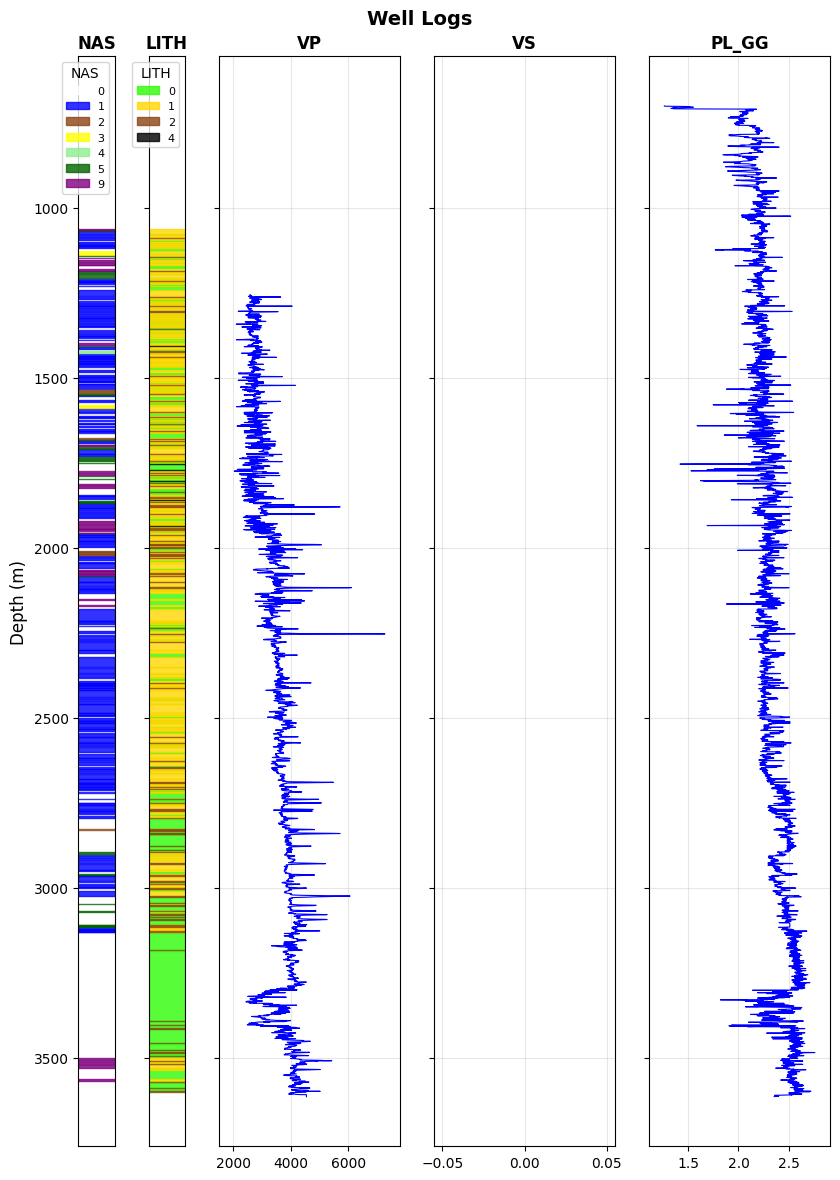

In [ ]:
plot_well_logs(las_dfs['Tgl-15'], ['NAS', 'LITH', 'VP', 'VS', 'PL_GG'])

In [ ]:
las_dfs_shale = {}
las_dfs_brine_sand = {}
las_dfs_oil_sand = {}
las_dfs_gas_sand = {}

# Apply filtering to all wells
las_dfs_shale, las_dfs_brine_sand, las_dfs_oil_sand, las_dfs_gas_sand = filter_wells_by_lithology(las_dfs)

Tgl-30: shale=2260, brine=1707, oil=142, gas=4
Tgl-26: shale=2806, brine=2255, oil=446, gas=94
Tgl-15: shale=2430, brine=1939, oil=427, gas=285
Tgl-29: shale=15536, brine=12102, oil=1081, gas=194
Tgl-8: shale=3158, brine=723, oil=1774, gas=55
Tgl-27: shale=848, brine=46, oil=215, gas=34


# Probabalistic models implementation

In [ ]:
# from sklearn.gaussian_process import GaussianProcessRegressor
# from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# def fit_gp_model(df, property_col, random_state=42):
#     """
#     Fit a Gaussian Process model to depth-property data.
    
#     Parameters:
#     -----------
#     df : pandas.DataFrame
#         DataFrame with depth as index
#     property_col : str
#         Column name (e.g., 'Vp', 'Vs', 'PL_GG')
#     random_state : int
#         Random seed for reproducibility
    
#     Returns:
#     --------
#     dict with keys:
#         'model' : fitted GPR model
#         'depth_range' : (min_depth, max_depth)
#         'r2_score' : model fit quality
#     """
#     # Extract data, drop NaNs
#     data = df[[property_col]].dropna()
#     X = data.index.values.reshape(-1, 1)  # depth as 2D array
#     y = data[property_col].values
    
#     if len(X) < 10:
#         print(f"Warning: Only {len(X)} data points for {property_col}")
#         return None
    
#     # Define kernel: RBF (smooth trend) + WhiteKernel (noise)
#     kernel = ConstantKernel(1.0) * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)
    
#     # Fit GPR
#     gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=random_state)
#     gpr.fit(X, y)
    
#     # Calculate R² score on training data
#     y_pred = gpr.predict(X)
#     r2 = 1 - np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)
    
#     depth_min, depth_max = X.min(), X.max()
    
#     print(f"{property_col}: R² = {r2:.3f}, kernel = {gpr.kernel_}")
    
#     return {
#         'model': gpr,
#         'depth_range': (depth_min, depth_max),
#         'r2_score': r2
#     }

# def fit_gp_model_all_wells(las_dfs_dict, property_col, max_points=2000, random_state=42):
#     """
#     Fit a GP model on subsampled data from all wells.
#     """
#     all_data = []
    
#     for well_name, df in las_dfs_dict.items():
#         if property_col in df.columns:
#             subset = df[[property_col]].dropna()
#             all_data.append(subset)
    
#     if not all_data:
#         print(f"No data found for {property_col}")
#         return None
    
#     combined_df = pd.concat(all_data)
    
    
#     print(f"Using {len(combined_df)} points for {property_col}")
    
#     return fit_gp_model(combined_df, property_col, random_state)

In [ ]:
pt.cuda.is_available()

True

In [18]:
result_shale = fit_gp_model_all_wells(
    las_dfs_shale,
    property_cols=['PL_GG', 'VP', 'VS'],
    max_points=10000,
    training_iter=100
)

PL_GG: subsampled from 27029 to 10000 points
PL_GG: trained on 10000 points, depth range (np.float64(1026.3000488), np.float64(4007.8000488))
VP: subsampled from 26900 to 10000 points
VP: trained on 10000 points, depth range (np.float64(1026.3000488), np.float64(4007.8000488))
VS: subsampled from 14396 to 10000 points
VS: trained on 10000 points, depth range (np.float64(1250.0), np.float64(3933.0))


[2.3108954 2.1707284 2.1513479 2.1673765 2.1569817 2.1309876 2.1351423
 2.148281  2.1549423 2.2125306 2.1892018 2.255214  2.2375286 2.2375286
 2.2375286 2.2785804 2.1957068 2.2125306 2.1787527 2.146911  2.153071
 2.1744936 2.1386693 2.1744936 2.1549425 2.1378882 2.1444418 2.146911
 2.1422791 2.1530707 2.146911  2.1569817 2.1513479 2.1403687 2.1386693
 2.135142  2.1339598 2.146911  2.148281  2.1403687 2.1836104 2.149756
 2.20337   2.1314318 2.146911  2.1787527 2.1787527 2.1422791 2.1314318
 2.1592133 2.1412947 2.1345375 2.1444418 2.1957068 2.1744936 2.1469107
 2.255214  2.1456337 2.1422791 2.1592133 2.2236755 2.1673765 2.139495
 2.1364458 2.1836104 2.1309884 2.1592133 2.20337   2.2375286 2.1592133
 2.1643724 2.148281  2.139495  2.1549425 2.1549425 2.1444418 2.1403687
 2.137888  2.1351423 2.1276789 2.1433256 2.1497562 2.1592133 2.1673765
 2.1412947 2.1250262 2.1592133 2.1497562 2.1643724 2.1643724 2.1957068
 2.153071  2.142279  2.20337   2.255214  2.255214  2.43586   2.1836104
 2.1569817

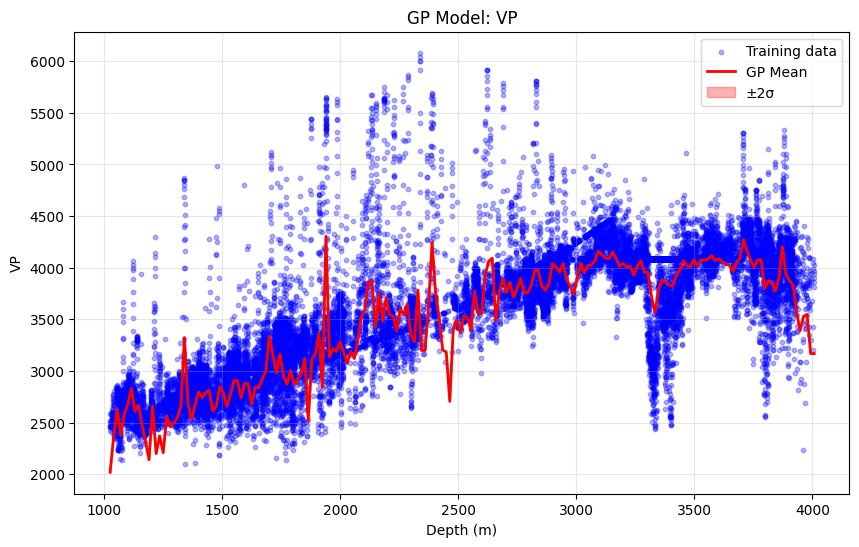

In [29]:
import matplotlib.pyplot as plt
import numpy as np
from util.gaussian_processes import predict_gp_model

def plot_gp_result(gp_result, well_data=None, property_name=None, n_points=200):
    """
    Plot GP model with optional training data overlay.
    
    Parameters
    ----------
    gp_result : dict
        Single result dict for one property (e.g., result_shale['PL_GG'])
    well_data : dict, optional
        Dictionary of {well_name: DataFrame} to overlay scatter points
    property_name : str, optional
        Property column name to plot from well_data
    n_points : int
        Number of points for smooth prediction curve
    """
    # Get prediction range from model's depth_range
    depth_min, depth_max = gp_result['depth_range']
    x_smooth = np.linspace(depth_min, depth_max, n_points)
    
    # Predict
    y_mean, y_std = predict_gp_model(gp_result, x_smooth)
    print(y_std)
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot training samples from wells
    if well_data is not None and property_name is not None:
        for well_name, df in well_data.items():
            if property_name in df.columns and 'DEPTH' in df.columns:
                valid = df[property_name].notna()
                ax.scatter(df.loc[valid, 'DEPTH'], 
                          df.loc[valid, property_name], 
                          alpha=0.3, s=10, c='blue', label='_nolegend_' if well_name != list(well_data.keys())[0] else 'Training data')
    
    # Plot GP mean and confidence
    ax.plot(x_smooth, y_mean, 'r-', linewidth=2, label='GP Mean')
    ax.fill_between(x_smooth, y_mean - 2*y_std, y_mean + 2*y_std, 
                    alpha=0.3, color='red', label='±2σ')
    
    ax.set_xlabel('Depth (m)')
    ax.set_ylabel(property_name or 'Property')
    ax.set_title(f'GP Model: {property_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return fig, ax


# Example usage:

# Plot single property
plot_gp_result(result_shale['VP'], las_dfs_shale, 'VP')
plt.show()

# # Plot all properties
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# for ax, prop in zip(axes, ['PL_GG', 'VP', 'VS']):
#     depth_min, depth_max = result_shale[prop]['depth_range']
#     x_smooth = np.linspace(depth_min, depth_max, 200)
#     y_mean, y_std = predict_gp_model(result_shale[prop], x_smooth)
    
#     # Scatter training data
#     for well_name, df in las_dfs_shale.items():
#         if prop in df.columns:
#             ax.scatter(df['DEPTH'], df[prop], alpha=0.2, s=5)
    
#     # GP curve
#     ax.plot(x_smooth, y_mean, 'r-', linewidth=2)
#     ax.fill_between(x_smooth, y_mean - 2*y_std, y_mean + 2*y_std, alpha=0.3, color='red')
#     ax.set_xlabel('Depth (m)')
#     ax.set_ylabel(prop)
#     ax.set_title(f'{prop} GP Model')

# plt.tight_layout()
# plt.show()

In [30]:
# Check what the model learned
result = result_shale['VP']
model = result['model']

print("Model hyperparameters:")
print(f"  Lengthscale: {model.covar_module.base_kernel.lengthscale.item():.2f}")
print(f"  Output scale: {model.covar_module.outputscale.item():.2f}")
print(f"  Noise: {result['likelihood'].noise.item():.6f}")
print(f"  Mean constant: {model.mean_module.constant.item():.2f}")

Model hyperparameters:
  Lengthscale: 0.69
  Output scale: 4.45
  Noise: 4.450290
  Mean constant: 6.34


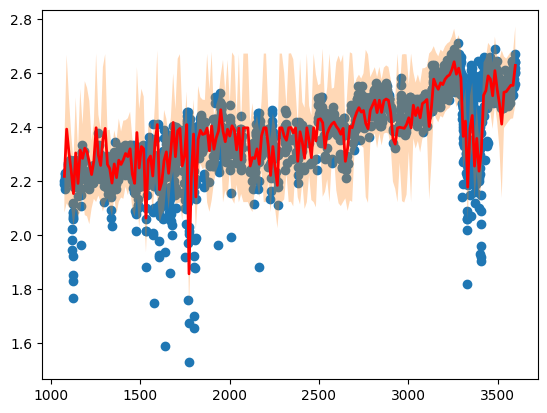

In [ ]:
x = las_dfs_shale['Tgl-15']['DEPTH']
y = las_dfs_shale['Tgl-15']['PL_GG']
x_smooth = np.linspace(x.min(), x.max(), 200).reshape(-1, 1)
y_mean, y_std = result['model'].predict(x_smooth, return_std=True)
plt.scatter(x, y)
plt.plot(x_smooth, y_mean, 'r-', label='GP Mean', linewidth=2)
plt.fill_between(x_smooth.flatten(), 
                y_mean - 2*y_std, 
                y_mean + 2*y_std, 
                alpha=0.3, label='±2σ')


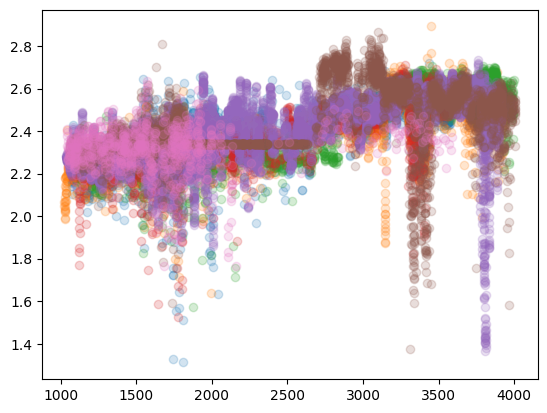

In [ ]:
for well in las_dfs_shale.keys():
    x = las_dfs_shale[well]['DEPTH']
    y = las_dfs_shale[well]['PL_GG']
    plt.scatter(x, y, alpha=0.2)